In [ ]:
# Importing necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [ ]:
# Set the base directory for the dataset
# Adjusting base_dir to point to the correct subdirectory within the downloaded path
# The actual data seems to be nested one level deeper under 'chest_xray'
base_dir = os.path.join(path, 'chest_xray', 'chest_xray')  # Corrected path

train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')
val_dir = os.path.join(base_dir, 'val')  # If you have a validation directory

# Check the directory structure
print("Contents of base_dir:", os.listdir(base_dir))
print("Train directory:", train_dir)
print("Test directory:", test_dir)
print("Validation directory:", val_dir)

# List contents of train directory to confirm
os.listdir(train_dir)


Contents of base_dir: ['val', '.DS_Store', 'test', 'train']
Train directory: /kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/train
Test directory: /kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/test
Validation directory: /kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val


['PNEUMONIA', 'NORMAL', '.DS_Store']

In [ ]:
# Data Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Creating generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    color_mode='rgb',
    shuffle=True
)

validation_generator = test_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224), # Changed to 224x224 to match MobileNetV2 common input size
    batch_size=32,
    class_mode='binary',
    color_mode='rgb'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    color_mode='rgb',
    shuffle=False
)
print(train_generator.class_indices)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
{'NORMAL': 0, 'PNEUMONIA': 1}


In [ ]:
# Load the MobileNetV2 model
base_model = MobileNetV2(
    input_shape=(224, 224, 3), # RGB input, changed to 224x224
    include_top=False, # Don't include the ImageNet classifier
    weights='imagenet' # Load weights pre-trained on ImageNet
)

# Freeze the base model to prevent its weights from being updated during training
base_model.trainable = False

# Build a new classification head on top of the base model
x = base_model.output
x = GlobalAveragePooling2D()(x) # Add a Global Average Pooling layer
x = Dense(128, activation='relu')(x) # Add a Dense layer with ReLU activation
x = Dropout(0.5)(x) # Add dropout for regularization
predictions = Dense(1, activation='sigmoid')(x) # Output layer for binary classification

# Create the new model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_8[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [58]:
# Training the model
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    callbacks=[
        EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True
        )
    ]
)


Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 362s 2s/step - accuracy: 0.9370 - loss: 0.1642 - val_accuracy: 0.9375 - val_loss: 0.2597
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 340s 2s/step - accuracy: 0.9395 - loss: 0.1479 - val_accuracy: 0.9375 - val_loss: 0.2454
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 343s 2s/step - accuracy: 0.9376 - loss: 0.1489 - val_accuracy: 0.8750 - val_loss: 0.2521
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 347s 2s/step - accuracy: 0.9436 - loss: 0.1465 - val_accuracy: 0.8750 - val_loss: 0.2508
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 332s 2s/step - accuracy: 0.9477 - loss: 0.1413 - val_accuracy: 0.9375 - val_loss: 0.2373
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 342s 2s/step - accuracy: 0.9508 - loss: 0.1313 - val_accuracy: 0.8750 - val_loss: 0.2733
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 329s 2s/step - accuracy: 0.9459 - loss: 0.1283 - val_accuracy: 0.8750 - val_loss: 0.2843
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 345s 2s/step - accuracy: 0.9412 - loss: 0.1375 - val_accu

In [59]:
# Evaluating the model
test_loss, test_acc = model.evaluate(test_generator, steps=len(test_generator))
print('Test accuracy:', test_acc)


20/20 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.8515 - loss: 0.3328
Test accuracy: 0.8926281929016113


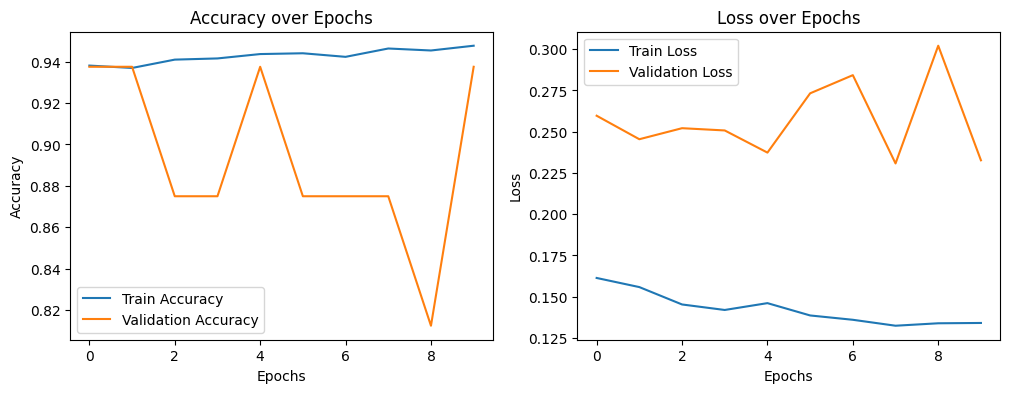

In [60]:
# Visualizing training history
plt.figure(figsize=(12, 4))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


In [63]:
import numpy as np

test_generator.reset()

pred = model.predict(test_generator, steps=len(test_generator))

pred_classes = (pred > 0.5).astype(int)

true_classes = test_generator.classes

20/20 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step


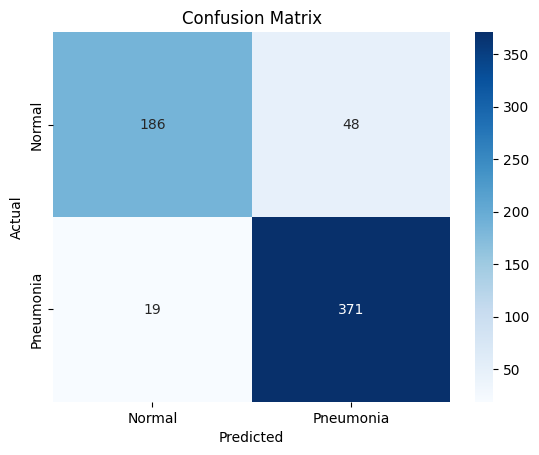

In [64]:
cm = confusion_matrix(true_classes, pred_classes)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Normal','Pneumonia'],
    yticklabels=['Normal','Pneumonia']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [65]:
print(classification_report(
    true_classes,
    pred_classes,
    target_names=['NORMAL','PNEUMONIA']
))

              precision    recall  f1-score   support

      NORMAL       0.91      0.79      0.85       234
   PNEUMONIA       0.89      0.95      0.92       390

    accuracy                           0.89       624
   macro avg       0.90      0.87      0.88       624
weighted avg       0.89      0.89      0.89       624



In [68]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(128,activation='relu')(x)
x = Dropout(0.5)(x)

predictions = Dense(1,activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)

In [ ]:
os.listdir(test_dir)

['PNEUMONIA', 'NORMAL', '.DS_Store']

In [69]:
normal_path = os.path.join(test_dir, 'NORMAL')
pneumonia_path = os.path.join(test_dir, 'PNEUMONIA')

print(os.listdir(normal_path)[:5])

['NORMAL2-IM-0336-0001.jpeg', 'IM-0101-0001.jpeg', 'NORMAL2-IM-0337-0001.jpeg', 'NORMAL2-IM-0198-0001.jpeg', 'IM-0013-0001.jpeg']


In [70]:
img_path = os.path.join(normal_path, 'IM-0101-0001.jpeg')

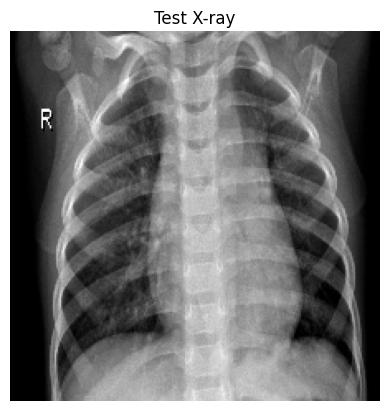

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Normal


In [72]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

img = image.load_img(img_path, target_size=(224,224))

plt.imshow(img)
plt.title("Test X-ray")
plt.axis('off')
plt.show()

img_array = image.img_to_array(img)
img_array = img_array / 255
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("Pneumonia detected")
else:
    print("Normal")

In [73]:
img_path = os.path.join(normal_path, 'NORMAL2-IM-0198-0001.jpeg')

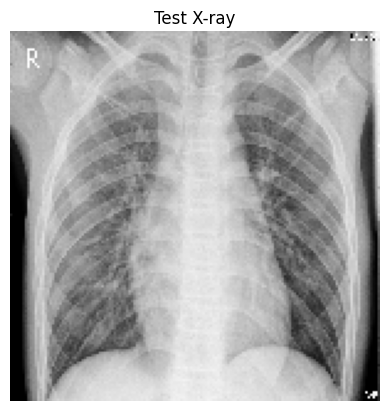

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Normal


In [74]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

img = image.load_img(img_path, target_size=(150,150))

plt.imshow(img)
plt.title("Test X-ray")
plt.axis('off')
plt.show()

img_array = image.img_to_array(img)
img_array = img_array / 255
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("Pneumonia detected")
else:
    print("Normal")